# The Tokyo 09:55 fix and "gotobi" days: is the USD/JPY anomaly still alive?

**The anomaly.** Japanese banks set their customer FX rate (the TTM) from the interbank USD/JPY price at **09:55 Tokyo**.
Corporate settlements cluster on *gotobi* days — the 5th, 10th, 15th, 20th, 25th and last business day of each month —
and Japanese importers are structural USD buyers. Ito & Yamada (2017) documented that USD/JPY drifts **up into 09:55 on
gotobi days** and partly reverts afterwards. Every Tokyo dealer knows it as the "gotobi buy".

**What we test, 2022–2026, on 1-minute data.**
1. Is 09:55 still a visible fix event?
2. Does the pre-fix drift on gotobi days still exist, ten years after publication?
3. Is there a post-fix reversal, and is it specific to gotobi days and to the fix time?
4. Does it survive a battery of significance tests (permutation, calendar shifts, placebo times, outliers, controls, forward walk)?
5. Is it tradeable after cost?

**Headline.** The pre-fix drift has been competed out of the 09:00–09:55 window (it now shows up 08:00–09:00). The
**post-fix unwind is alive**: on gotobi days USD/JPY falls ≈ 2.5 bp in 09:55–10:30 vs ≈ 0 on other days (p = 0.003,
robust to everything below). Shorting USD/JPY 09:55→10:30 on gotobi days nets ≈ +2 bp per trade at a Sharpe ≈ 1.5 —
with the caveat that 2026 is the weakest year in the sample.

## 1. Data
**What this does.** USD/JPY 1-minute OHLC from Twelve Data (free tier: 8 calls/min, 800/day, 5,000 bars/call), pulled
backwards from today in pages, checkpointed to `data/usdjpy_1m.csv`. The pull is *skipped* by default so opening the
notebook doesn't spend API credits; set `RUN_PULL = True` to extend the history (it resumes from the oldest bar saved).

In [1]:
RUN_PULL = False        # True → (re)download / extend data/usdjpy_1m.csv; needs twelvedata.key next to this notebook
if RUN_PULL:
    import os, time, math, requests, pandas as pd
    from collections import deque
    API_KEY, SYMBOL, INTERVAL, TZ = open("twelvedata.key").read().strip(), "USD/JPY", "1min", "Asia/Tokyo"
    OUTPUTSIZE, FLOOR_DATE, PER_MIN, OUT_CSV = 5000, pd.Timestamp("2020-04-01"), 8, "data/usdjpy_1m.csv"
    os.makedirs("data", exist_ok=True); URL = "https://api.twelvedata.com/time_series"
    calls = deque()
    def wait():
        now = time.time()
        while calls and now - calls[0] >= 60: calls.popleft()
        if len(calls) >= PER_MIN: time.sleep(max(60 - (now - calls[0]) + 0.2, 0))
        calls.append(time.time())
    def fetch(end_date):
        while True:
            wait()
            r = requests.get(URL, params=dict(symbol=SYMBOL, interval=INTERVAL, outputsize=OUTPUTSIZE, timezone=TZ,
                                              end_date=end_date.strftime("%Y-%m-%d %H:%M:%S"), apikey=API_KEY), timeout=30).json()
            if r.get("status") == "error":
                msg, code = r.get("message", ""), r.get("code")
                if code == 429 and "for the day" in msg: return None, "daily_limit"
                if code == 429: time.sleep(60 - time.time() % 60 + 0.5); continue
                if code in (400, 404): return None, "nodata"
                raise RuntimeError(f"API error {code}: {msg}")
            vals = r.get("values", [])
            if not vals: return None, "nodata"
            df = pd.DataFrame(vals); df["datetime"] = pd.to_datetime(df["datetime"])
            for c in ["open", "high", "low", "close"]: df[c] = df[c].astype(float)
            return df[["datetime", "open", "high", "low", "close"]], "ok"
    if os.path.exists(OUT_CSV) and os.path.getsize(OUT_CSV) > 0:
        end_date = pd.to_datetime(pd.read_csv(OUT_CSV, usecols=["datetime"])["datetime"]).min() - pd.Timedelta(minutes=1)
    else:
        end_date = pd.Timestamp.now(tz=TZ).tz_localize(None) + pd.Timedelta(days=1)
    n = 0
    while end_date >= FLOOR_DATE:
        page, status = fetch(end_date)
        if status != "ok": print(status); break
        page.to_csv(OUT_CSV, mode="a", header=not os.path.exists(OUT_CSV) or os.path.getsize(OUT_CSV) == 0, index=False)
        end_date = page.datetime.min() - pd.Timedelta(minutes=1); n += 1
        if n % 25 == 0: print(f"{n} calls, oldest {end_date}")
    print(f"done: {n} calls, oldest = {end_date}")
else:
    print("pull skipped (RUN_PULL = False); using existing data/usdjpy_1m.csv")

pull skipped (RUN_PULL = False); using existing data/usdjpy_1m.csv


**What this does.** Loads the 1-minute file, keeps Tokyo hours **08:00–14:59**, removes bad prints (>5 % off the day's
median, or >100 bp off an 11-minute rolling median), keeps only full sessions, drops Japanese holidays (no fix), and
lays the data out as a *days × minutes* price grid. Minute 0 = 08:00; the fix price is the 09:54 close (= 09:55:00).
All returns below are log returns in **basis points**; positive = USD/JPY up (yen weaker).

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, holidays
from scipy import stats
import statsmodels.api as sm
import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

raw = pd.read_csv("data/usdjpy_1m.csv", parse_dates=["datetime"]).drop_duplicates("datetime").sort_values("datetime")
raw["date"] = raw.datetime.dt.normalize()
raw = raw[(raw.datetime.dt.dayofweek < 5) & (raw.datetime.dt.hour >= 8) & (raw.datetime.dt.hour < 15)]
raw["minute"] = (raw.datetime.dt.hour - 8) * 60 + raw.datetime.dt.minute
dmed = raw.groupby("date").close.transform("median")
raw = raw[(np.log(raw.close / dmed) * 1e4).abs() <= 500]
med = raw.groupby("date").close.transform(lambda s: s.rolling(11, center=True, min_periods=3).median())
raw = raw[(np.log(raw.close / med) * 1e4).abs() <= 100]
jp = holidays.JP(years=range(2019, 2028))
g = raw.groupby("date"); ok = (g.size() >= 300) & (g.minute.min() <= 5) & (g.minute.max() >= 415)
days = ok[ok].index; days = days[[d.date() not in jp for d in days]]
raw = raw[raw.date.isin(days)]
px = raw.pivot(index="date", columns="minute", values="close").reindex(columns=range(420)).ffill(axis=1).bfill(axis=1)
lpx = np.log(px); r1 = lpx.diff(axis=1) * 1e4
def bp(a, b): return (lpx[b] - lpx[a]) * 1e4
def lab(m): return f"{8 + m // 60:02d}:{m % 60:02d}"
FIX = 114
years = px.index.year
print(f"{len(px)} Tokyo sessions, {px.index.min().date()} → {px.index.max().date()}")

1082 Tokyo sessions, 2022-04-12 → 2026-09-16


**What this does.** Builds the gotobi calendar: the 5th/10th/15th/20th/25th and the last business day of each month.
If one falls on a weekend or Japanese holiday it is moved **back** to the previous business day (the settlement convention).

In [3]:
def is_bday(d): return d.weekday() < 5 and d.date() not in jp
gotobi_dates, kind = set(), {}
for m in pd.period_range(px.index.min(), px.index.max(), freq="M"):
    for dd in [5, 10, 15, 20, 25, "eom"]:
        d = m.end_time.normalize() if dd == "eom" else pd.Timestamp(m.year, m.month, dd)
        while not is_bday(d): d -= pd.Timedelta(days=1)
        gotobi_dates.add(d); kind[d] = "eom" if dd == "eom" else str(dd)
G = pd.Series(px.index.isin(gotobi_dates), index=px.index, name="gotobi")
K = pd.Series([kind.get(d, "none") for d in px.index], index=px.index)
print(f"gotobi sessions: {G.sum()} of {len(G)} ({G.mean():.1%});  by type: {K[G].value_counts().to_dict()}")

gotobi sessions: 313 of 1082 (28.9%);  by type: {'15': 54, 'eom': 53, '20': 52, '5': 52, '10': 52, '25': 50}


## 2. Is 09:55 a fix event?
**What this does.** Mean absolute 1-minute return around 09:55, gotobi vs other days (left), and the cumulative signed
return from 09:24 (right). A fix should show as a volatility spike; the gotobi story predicts a signed drift too.

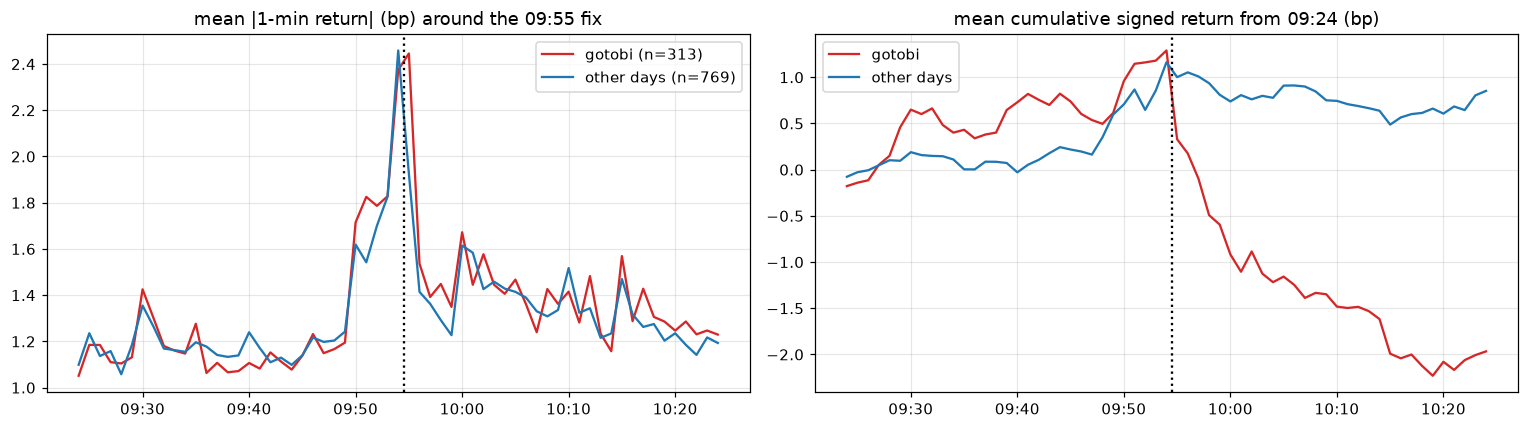

|move| in the 09:54–09:55 bars: 4.51 bp vs 2.65 bp for two neighbouring minutes (ratio 1.70, Wilcoxon p = 5.4e-89)
gotobi 4.82 bp vs other 4.39 bp (Mann–Whitney p = 0.072)


In [4]:
z = range(84, 145)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for l, m_, c in [("gotobi", G, "C3"), ("other days", ~G, "C0")]:
    ax[0].plot(z, r1.loc[m_, list(z)].abs().mean(), color=c, label=f"{l} (n={m_.sum()})")
    ax[1].plot(z, r1.loc[m_, list(z)].mean().cumsum(), color=c, label=l)
ax[0].set_title("mean |1-min return| (bp) around the 09:55 fix"); ax[1].set_title("mean cumulative signed return from 09:24 (bp)")
for a in ax:
    a.axvline(FIX + .5, color="k", ls=":"); a.set_xticks(range(90, 145, 10)); a.set_xticklabels([lab(m) for m in range(90, 145, 10)]); a.legend()
plt.tight_layout(); plt.show()
fx = r1[[114, 115]].abs().sum(axis=1); nb = r1[list(range(100, 112)) + list(range(118, 130))].abs().mean(axis=1) * 2
print(f"|move| in the 09:54–09:55 bars: {fx.mean():.2f} bp vs {nb.mean():.2f} bp for two neighbouring minutes (ratio {fx.mean() / nb.mean():.2f}, Wilcoxon p = {stats.wilcoxon(fx - nb).pvalue:.1e})")
print(f"gotobi {fx[G].mean():.2f} bp vs other {fx[~G].mean():.2f} bp (Mann–Whitney p = {stats.mannwhitneyu(fx[G], fx[~G]).pvalue:.3f})")

**Interpretation.** The fix is unmistakable: the two minutes at 09:55 move 1.7× as much as their neighbours
(p ≈ 10⁻⁸⁹), and slightly more on gotobi days. On the right, gotobi days (red) rise into 09:55 and then drop sharply in
the minutes after it, while other days (blue) are flat. That is the shape Ito & Yamada described — but note how much of
the red line's rise happens *before* 09:30.

## 3. Pre-fix drift and post-fix reversal
**What this does.** Compares gotobi vs other days in fixed windows — before the fix (09:00→09:55, 09:30→09:55,
09:45→09:55), after it (09:55→10:30, 09:55→11:00) and the early morning (08:00→09:00) — with Welch t-tests and
Mann–Whitney tests, then plots the average price path from 09:00 with 95 % confidence bands.

window          gotobi mean  other mean    diff   Welch p      MW p  gotobi %up
09:00→09:55            1.28        0.91    0.37     0.709     0.395       56.9%
09:30→09:55            0.64        0.97   -0.33     0.588     0.557       55.0%
09:45→09:55            0.55        0.94   -0.39     0.419     0.476       53.4%
09:55→10:30           -2.54       -0.29   -2.25     0.003     0.001       39.3%
09:55→11:00           -2.55       -0.65   -1.90     0.045     0.110       43.5%
08:00→09:00            0.89       -0.57    1.46     0.032     0.009       57.2%


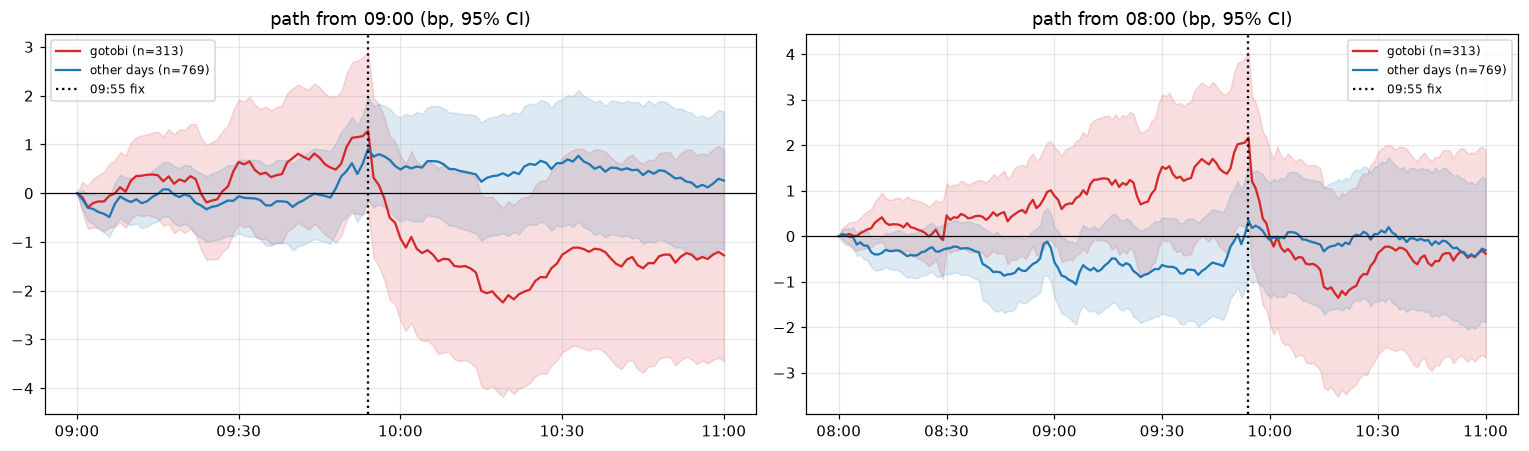


09:55→10:30 regressed on the pre-fix move, a gotobi dummy and their interaction (HC3):
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.2536      0.441     -0.576      0.565      -1.117       0.610
pre_fix_move    -0.0418      0.084     -0.495      0.621      -0.207       0.124
gotobi          -2.1772      0.794     -2.743      0.006      -3.733      -0.622
pre_x_gotobi    -0.1335      0.130     -1.030      0.303      -0.387       0.120


In [5]:
W = {"09:00→09:55": (60, FIX), "09:30→09:55": (90, FIX), "09:45→09:55": (105, FIX), "09:55→10:30": (FIX, 150), "09:55→11:00": (FIX, 180), "08:00→09:00": (0, 60)}
D = pd.DataFrame({k: bp(*v) for k, v in W.items()}); D["gotobi"] = G; D["kind"] = K; D["year"] = years
print(f"{'window':14s} {'gotobi mean':>12s} {'other mean':>11s} {'diff':>7s} {'Welch p':>9s} {'MW p':>9s} {'gotobi %up':>11s}")
for k in W:
    a, b = D.loc[G, k], D.loc[~G, k]
    print(f"{k:14s} {a.mean():12.2f} {b.mean():11.2f} {a.mean() - b.mean():7.2f} {stats.ttest_ind(a, b, equal_var=False).pvalue:9.3f} {stats.mannwhitneyu(a, b).pvalue:9.3f} {(a > 0).mean():11.1%}")
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
for a_, start, ttl in [(ax[0], 60, "path from 09:00 (bp, 95% CI)"), (ax[1], 0, "path from 08:00 (bp, 95% CI)")]:
    path = (lpx.sub(lpx[start], axis=0) * 1e4).loc[:, start:180]
    for l, m_, c in [("gotobi", G, "C3"), ("other days", ~G, "C0")]:
        p = path[m_]; mu, se = p.mean(), p.std() / np.sqrt(len(p))
        a_.plot(p.columns, mu, color=c, label=f"{l} (n={m_.sum()})"); a_.fill_between(p.columns, mu - 1.96 * se, mu + 1.96 * se, color=c, alpha=.15)
    a_.axvline(FIX, color="k", ls=":", label="09:55 fix"); a_.axhline(0, color="k", lw=.8); a_.legend(fontsize=8); a_.set_title(ttl)
    a_.set_xticks(range(start, 181, 30)); a_.set_xticklabels([lab(m) for m in range(start, 181, 30)])
plt.tight_layout(); plt.show()
m = sm.OLS(D["09:55→10:30"], sm.add_constant(pd.DataFrame({"pre_fix_move": D["09:30→09:55"], "gotobi": G.astype(float), "pre_x_gotobi": D["09:30→09:55"] * G})), missing="drop").fit(cov_type="HC3")
print("\n09:55→10:30 regressed on the pre-fix move, a gotobi dummy and their interaction (HC3):"); print(m.summary().tables[1])

**Interpretation.**
- **The textbook drift is gone.** 09:00→09:55 on gotobi days is +1.3 bp vs +0.9 bp on other days — no difference (p = 0.7).
- **It moved earlier.** 08:00→09:00 is +0.9 bp on gotobi vs −0.6 bp otherwise (p = 0.03; Mann–Whitney 0.009). The
  importer demand is being front-run before most Tokyo desks are in. The right-hand chart shows the whole climb now
  happens 08:00–09:55.
- **The post-fix reversal is alive.** 09:55→10:30 is **−2.5 bp on gotobi days vs −0.3 bp** on other days (Welch
  p = 0.003, Mann–Whitney p = 0.001). Only 39 % of gotobi days are up in that window. In the regression the gotobi dummy
  is −2.2 bp (t = −2.7) *after* controlling for the size of the pre-fix move — it's the day type, not just the size of the run-up.
- Round trip 08:00→10:30 on gotobi days nets to ≈ 0: everything bought into the fix is sold back after it.

## 4. Which gotobi days, and is it stable over time?
**What this does.** Splits the pre-fix and post-fix returns by settlement-day type (5/10/15/20/25/month-end) and shows the
gotobi-minus-other post-fix difference year by year.

        n   pre  pre_sd  post  post_sd
kind                                  
5      52 -2.15   13.74 -1.08    11.13
10     52 -1.80   18.35 -0.84    11.45
15     54  2.40   12.84 -1.68    11.81
20     52  2.24   11.16 -3.24    11.89
25     50  3.16   14.37 -3.59    10.92
eom    53  3.81   16.15 -4.86    11.52
none  769  0.91   14.97 -0.29    11.36

post-fix (09:55→10:30) gotobi vs other, by year:
      gotobi  other   n_g      p   diff
2022  -4.739 -2.363  50.0  0.279 -2.376
2023  -1.945  0.249  71.0  0.211 -2.194
2024  -2.827 -0.298  71.0  0.104 -2.529
2025  -3.356 -0.293  70.0  0.065 -3.063
2026   0.287  1.048  51.0  0.572 -0.761


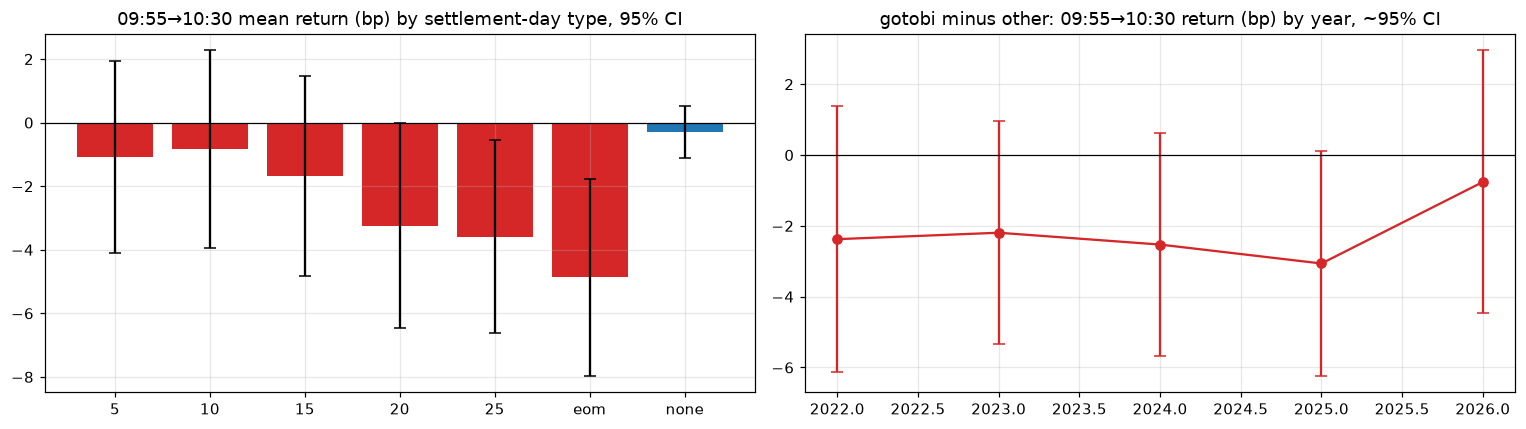

In [6]:
T = D.groupby("kind").agg(n=("09:00→09:55", "size"), pre=("09:00→09:55", "mean"), pre_sd=("09:00→09:55", "std"), post=("09:55→10:30", "mean"), post_sd=("09:55→10:30", "std")).loc[["5", "10", "15", "20", "25", "eom", "none"]]
print(T.round(2))
post = D["09:55→10:30"]
Yp = pd.DataFrame({y: dict(gotobi=post[G & (years == y)].mean(), other=post[~G & (years == y)].mean(), n_g=int((G & (years == y)).sum()),
                            p=stats.ttest_ind(post[G & (years == y)], post[~G & (years == y)], equal_var=False).pvalue) for y in sorted(set(years))}).T
Yp["diff"] = Yp.gotobi - Yp.other; print("\npost-fix (09:55→10:30) gotobi vs other, by year:"); print(Yp.round(3))
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(T.index, T.post, yerr=1.96 * T.post_sd / np.sqrt(T.n), capsize=4, color=["C3"] * 6 + ["C0"]); ax[0].axhline(0, color="k", lw=.8)
ax[0].set_title("09:55→10:30 mean return (bp) by settlement-day type, 95% CI")
ax[1].errorbar(Yp.index.astype(int), Yp["diff"], yerr=1.96 * np.sqrt(post[G].var() / Yp.n_g + post[~G].var() / (Yp.n_g * 2.5)), fmt="o-", capsize=4, color="C3"); ax[1].axhline(0, color="k", lw=.8)
ax[1].set_title("gotobi minus other: 09:55→10:30 return (bp) by year, ~95% CI")
plt.tight_layout(); plt.show()

**Interpretation.** The reversal is carried by the **20th, 25th and month-end** (−3.2, −3.6, −4.9 bp) — the heavy
settlement days — while the 5th and 10th contribute little. Those same days are the only ones where the *pre*-fix drift
survives (+3.2 / +3.8 bp on the 25th and EOM). Year by year the post-fix difference is negative in **2022, 2023, 2024 and
2025** (−2.2 to −3.1 bp) and shrinks to −0.8 bp in **2026** (n = 51). Either a thin year or the effect being competed away — we can't tell yet.

## 5. Is it significant? A stress test
**What this does.** One significant window out of six deserves more than a t-stat. (a) **Permutation**: reassign the
gotobi label to random days 5,000 times. (b) **Calendar shift**: move the gotobi calendar by ±1…±10 business days —
a real settlement effect should vanish at every shift. (c) **Placebo times**: the same gotobi-vs-other test in 35-minute
windows at every other time of day — the effect should be specific to windows containing 09:55.

(a) permutation: observed diff = -2.25 bp;  two-sided p = 0.0030;  null sd = 0.77 bp → z = -2.94
(b) calendar shift: true dates -2.25 bp (p 0.003);  shifted calendars: mean +0.28, range [-1.32, +2.07];  true dates rank 1 of 21
(c) placebo times: windows containing the fix: t from -4.12 to -2.03;  clean windows elsewhere: |t| > 2 in 4 of 60 (≈3 expected by chance)


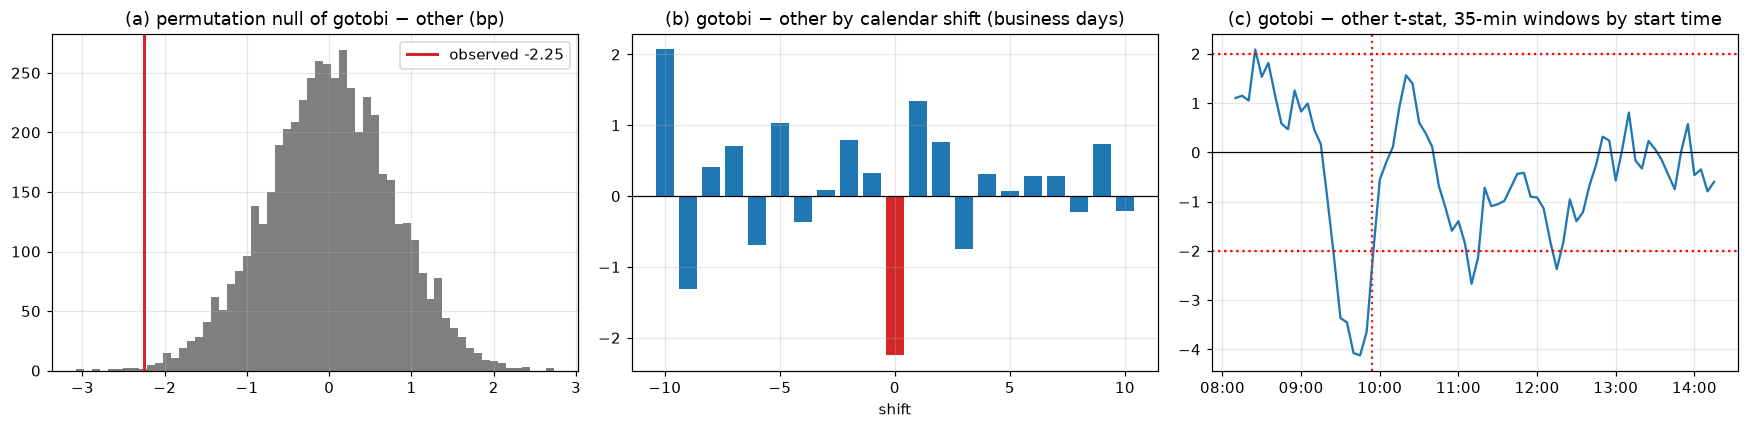

In [7]:
rng = np.random.default_rng(1)
y = D["09:55→10:30"]; gg = G.values; obs = y[gg].mean() - y[~gg].mean()
perm = np.array([(lambda m: y[m].mean() - y[~m].mean())(rng.permutation(gg)) for _ in range(5000)])
print(f"(a) permutation: observed diff = {obs:+.2f} bp;  two-sided p = {(np.abs(perm) >= abs(obs)).mean():.4f};  null sd = {perm.std():.2f} bp → z = {obs / perm.std():.2f}")
bd = pd.Series(np.arange(len(px)), index=px.index); sh = []
for k in range(-10, 11):
    idx = bd[G].values + k; idx = idx[(idx >= 0) & (idx < len(px))]; m = np.zeros(len(px), bool); m[idx] = True
    sh.append(dict(shift=k, diff=y[m].mean() - y[~m].mean(), p=stats.ttest_ind(y[m], y[~m], equal_var=False).pvalue))
SH = pd.DataFrame(sh).set_index("shift")
print(f"(b) calendar shift: true dates {SH.loc[0, 'diff']:+.2f} bp (p {SH.loc[0, 'p']:.3f});  shifted calendars: mean {SH.drop(0)['diff'].mean():+.2f}, range [{SH.drop(0)['diff'].min():+.2f}, {SH.drop(0)['diff'].max():+.2f}];  true dates rank {int((SH['diff'] <= SH.loc[0, 'diff']).sum())} of 21")
pt = []
for t0 in range(10, 380, 5):
    r_ = bp(t0, t0 + 35); pt.append(dict(t=t0, tstat=stats.ttest_ind(r_[G], r_[~G], equal_var=False).statistic))
PT = pd.DataFrame(pt).set_index("t"); clean = PT[(PT.index < FIX - 35) | (PT.index > FIX + 35)]
print(f"(c) placebo times: windows containing the fix: t from {PT.loc[95:115, 'tstat'].min():.2f} to {PT.loc[95:115, 'tstat'].max():.2f};  clean windows elsewhere: |t| > 2 in {(clean.tstat.abs() > 2).sum()} of {len(clean)} (≈{0.05 * len(clean):.0f} expected by chance)")
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].hist(perm, bins=60, color="C7"); ax[0].axvline(obs, color="C3", lw=2, label=f"observed {obs:+.2f}"); ax[0].set_title("(a) permutation null of gotobi − other (bp)"); ax[0].legend()
ax[1].bar(SH.index, SH["diff"], color=["C3" if k == 0 else "C0" for k in SH.index]); ax[1].axhline(0, color="k", lw=.8); ax[1].set_title("(b) gotobi − other by calendar shift (business days)"); ax[1].set_xlabel("shift")
ax[2].plot(PT.index, PT.tstat); ax[2].axhline(0, color="k", lw=.8); ax[2].axhline(-2, color="r", ls=":"); ax[2].axhline(2, color="r", ls=":"); ax[2].axvline(FIX, color="C3", ls=":")
ax[2].set_xticks(range(0, 420, 60)); ax[2].set_xticklabels([lab(m) for m in range(0, 420, 60)]); ax[2].set_title("(c) gotobi − other t-stat, 35-min windows by start time")
plt.tight_layout(); plt.show()

**Interpretation.** (a) The observed −2.25 bp sits far in the tail of the permutation null (p = 0.003, z ≈ −2.9).
(b) The true calendar is the most negative of all 21 shifts; shifted calendars average +0.3 bp — it is *these* dates.
(c) Every window with |t| > 3 contains 09:55; away from the fix, |t| > 2 appears at roughly the chance rate. The effect
is specific to the fix, and most of the unwind happens in the first ~20 minutes after it.

**What this does.** (d) **Heavy tails**: trimmed and winsorised means, medians, vol-standardised returns, a bootstrap CI and
a sign test. (e) **Confounds**: regress the post-fix return on the gotobi dummy with weekday, year, month-end,
month-start, pre-fix move, 08:00–09:00 move, overnight move and trailing-volatility controls. (f) **Forward walk**:
trade each year only if the *previous* years' pooled evidence was already significant at 10 %.

In [8]:
a, b = y[gg], y[~gg]
tr = lambda s, q: s[(s > s.quantile(q)) & (s < s.quantile(1 - q))]
wz = lambda s, q: s.clip(s.quantile(q), s.quantile(1 - q))
boot = np.array([rng.choice(a, len(a)).mean() - rng.choice(b, len(b)).mean() for _ in range(5000)])
vol = (np.log(px.max(axis=1) / px.min(axis=1)) * 1e4).shift(1).rolling(20).mean(); yz = y / vol
print(f"(d) raw {obs:+.2f} | 5% trimmed {tr(a, .05).mean() - tr(b, .05).mean():+.2f} | 5% winsorised {wz(a, .05).mean() - wz(b, .05).mean():+.2f} | medians {a.median():+.2f} vs {b.median():+.2f} | vol-standardised t = {stats.ttest_ind(yz[gg].dropna(), yz[~gg].dropna(), equal_var=False).statistic:.2f}")
print(f"    bootstrap 95% CI [{np.percentile(boot, 2.5):+.2f}, {np.percentile(boot, 97.5):+.2f}] | share of days negative: gotobi {(a < 0).mean():.1%} vs other {(b < 0).mean():.1%}, 2-proportion p = {sm.stats.proportions_ztest([(a < 0).sum(), (b < 0).sum()], [len(a), len(b)])[1]:.4f}")
X = pd.DataFrame({"gotobi": G.astype(float), "eom": (K == "eom").astype(float), "pre_fix": bp(60, FIX), "early": bp(0, 60),
                  "overnight": (lpx[0] - lpx[419].shift(1)) * 1e4, "range_20d": vol, "month_start": (px.index.day <= 3).astype(float)})
X = pd.concat([X, pd.get_dummies(px.index.weekday, prefix="wd", drop_first=True).set_index(px.index).astype(float),
               pd.get_dummies(years, prefix="y", drop_first=True).set_index(px.index).astype(float)], axis=1)
m = sm.OLS(y, sm.add_constant(X), missing="drop").fit(cov_type="HC3")
print(f"(e) with all controls: gotobi β = {m.params.gotobi:+.2f} bp (t {m.tvalues.gotobi:.2f}, p {m.pvalues.gotobi:.4f});  EOM extra = {m.params.eom:+.2f} (t {m.tvalues.eom:.2f});  "
      f"excluding EOM days entirely: β = {sm.OLS(y[K != 'eom'], sm.add_constant(X.drop(columns='eom')[K != 'eom']), missing='drop').fit(cov_type='HC3').params.gotobi:+.2f}")
COST = 0.5
print("(f) forward walk — trade year Y only if pooled prior years show gotobi − other < 0 with p < 0.10:")
for yv in sorted(set(years))[1:]:
    pa, pb = y[gg & (years < yv)], y[~gg & (years < yv)]; pv = stats.ttest_ind(pa, pb, equal_var=False).pvalue; go = (pa.mean() - pb.mean() < 0) and pv < .10
    r = -y[gg & (years == yv)] - COST
    print(f"    {yv}: prior p = {pv:.3f} → {'TRADE' if go else 'skip '}   realised net = {r.mean():+.2f} bp on {len(r)} trades (hit {(r > 0).mean():.0%})")

(d) raw -2.25 | 5% trimmed -2.27 | 5% winsorised -2.38 | medians -2.23 vs +0.00 | vol-standardised t = -2.42
    bootstrap 95% CI [-3.77, -0.77] | share of days negative: gotobi 59.7% vs other 49.8%, 2-proportion p = 0.0030
(e) with all controls: gotobi β = -2.71 bp (t -3.28, p 0.0010);  EOM extra = -2.65 (t -1.44);  excluding EOM days entirely: β = -2.74
(f) forward walk — trade year Y only if pooled prior years show gotobi − other < 0 with p < 0.10:
    2023: prior p = 0.279 → skip    realised net = +1.45 bp on 71 trades (hit 56%)
    2024: prior p = 0.100 → skip    realised net = +2.33 bp on 71 trades (hit 58%)
    2025: prior p = 0.023 → TRADE   realised net = +2.86 bp on 70 trades (hit 56%)
    2026: prior p = 0.004 → TRADE   realised net = -0.79 bp on 51 trades (hit 51%)


**Interpretation.** (d) Nothing depends on outliers: trimmed, winsorised and median versions are all ≈ −2.3 bp, the
bootstrap CI [−3.8, −0.8] excludes zero, and 60 % of gotobi days are down after the fix vs 50 % of other days (p = 0.003).
(e) With every control we can think of the gotobi effect is **−2.7 bp, t = −3.3, p = 0.001**, and it is not a month-end
artefact. (f) The honest weak spot: a rule that waited for prior-year significance would have traded only 2025 (+2.9 bp)
and 2026 (−0.8 bp). 2023 and 2024 were profitable but you would not yet have had the evidence to trade them.

## 6. Is it tradeable?
**What this does.** The rule: on gotobi days, **short USD/JPY at 09:55, cover at 10:30**. Reported net of a round-trip
cost (0.5 bp is conservative for interbank USD/JPY; the table also shows 0.3–2.0 bp), with the same rule on non-gotobi
days as a placebo, plus the surviving *pre*-fix leg (long 09:00→09:55 on the 25th and month-end only).

short 09:55→10:30, gotobi days, net 0.5 bp     n= 313  mean= +2.04 bp  hit=58.1%  t= 3.15  Sharpe≈ 1.52
   placebo: same rule on non-gotobi days       n= 769  mean= -0.21 bp  hit=48.0%  t=-0.50  Sharpe≈-0.24
long 09:00→09:55, 25th & month-end only        n= 103  mean= +2.99 bp  hit=63.1%  t= 1.99  Sharpe≈ 0.96

cost sensitivity of the short leg:
   cost 0.3 bp: mean +2.24 bp  t 3.46  Sharpe≈1.67  worst trade -44 bp  worst 20-trade run -59 bp  80% of years positive
   cost 0.5 bp: mean +2.04 bp  t 3.15  Sharpe≈1.52  worst trade -44 bp  worst 20-trade run -63 bp  80% of years positive
   cost 1.0 bp: mean +1.54 bp  t 2.38  Sharpe≈1.15  worst trade -45 bp  worst 20-trade run -73 bp  80% of years positive
   cost 1.5 bp: mean +1.04 bp  t 1.61  Sharpe≈0.78  worst trade -45 bp  worst 20-trade run -83 bp  80% of years positive
   cost 2.0 bp: mean +0.54 bp  t 0.84  Sharpe≈0.40  worst trade -46 bp  worst 20-trade run -93 bp  60% of years positive


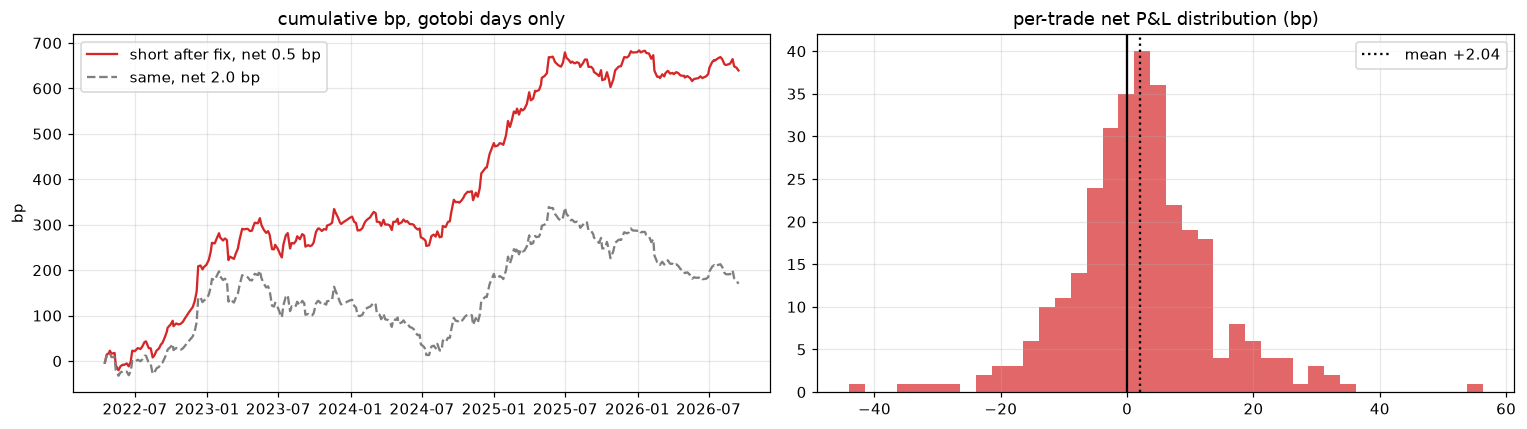

In [9]:
def rep(r, label):
    n = len(r); print(f"{label:46s} n={n:4d}  mean={r.mean():+6.2f} bp  hit={(r > 0).mean():5.1%}  t={r.mean() / r.std() * np.sqrt(n):5.2f}  Sharpe≈{r.mean() / r.std() * np.sqrt(252 * n / len(D)):5.2f}")
    return r
short_g = rep(-D.loc[G, "09:55→10:30"] - COST, "short 09:55→10:30, gotobi days, net 0.5 bp")
rep(-D.loc[~G, "09:55→10:30"] - COST, "   placebo: same rule on non-gotobi days")
long_25 = rep(D.loc[G & K.isin(["25", "eom"]), "09:00→09:55"] - COST, "long 09:00→09:55, 25th & month-end only")
print("\ncost sensitivity of the short leg:")
r0 = -D.loc[G, "09:55→10:30"]
for c in [0.3, 0.5, 1.0, 1.5, 2.0]:
    r = r0 - c; print(f"   cost {c:.1f} bp: mean {r.mean():+.2f} bp  t {r.mean() / r.std() * np.sqrt(len(r)):.2f}  Sharpe≈{r.mean() / r.std() * np.sqrt(252 * len(r) / len(D)):.2f}  worst trade {r.min():.0f} bp  worst 20-trade run {r.rolling(20).sum().min():+.0f} bp  {(r.groupby(years[gg]).sum() > 0).mean():.0%} of years positive")
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(short_g.cumsum(), label="short after fix, net 0.5 bp", color="C3"); ax[0].plot((r0 - 2.0).cumsum(), label="same, net 2.0 bp", color="C7", ls="--"); ax[0].legend(); ax[0].set_title("cumulative bp, gotobi days only"); ax[0].set_ylabel("bp")
ax[1].hist(short_g, bins=40, color="C3", alpha=.7); ax[1].axvline(0, color="k"); ax[1].axvline(short_g.mean(), color="k", ls=":", label=f"mean {short_g.mean():+.2f}"); ax[1].legend(); ax[1].set_title("per-trade net P&L distribution (bp)")
plt.tight_layout(); plt.show()

**Interpretation.** Short USD/JPY 09:55→10:30 on gotobi days: **+2.0 bp per trade net of 0.5 bp, 58 % hit rate, t = 3.2,
Sharpe ≈ 1.5** on ~70 trades a year. The identical rule on non-gotobi days loses 0.2 bp (placebo passes). It survives a
1 bp cost (t = 2.4) but not 2 bp — so it is an interbank-cost edge, not a retail one. The 25th/month-end pre-fix long
adds +3.0 bp per trade (t = 2.0) on ~24 days a year. The distribution is fat-tailed (worst trade −44 bp on a BoJ-type
day; a −60 bp 20-trade run is in the history), so position sizing matters more than the mean suggests.

## 7. Conclusion

| question | answer |
|---|---|
| Is 09:55 still a fix event? | Yes — 1.7× the volatility of neighbouring minutes, every year. |
| Is the classic gotobi pre-fix drift still there? | Not in 09:00–09:55. It has been front-run into **08:00–09:00**, and survives only on the 25th and month-end. |
| Is there a post-fix reversal? | **Yes: −2.5 bp on gotobi days vs ≈ 0 otherwise**, concentrated in the first 20 minutes after the fix, carried by the 20th/25th/month-end. |
| Is it significant? | Permutation p = 0.003; true calendar beats all 21 shifts; specific to the fix time; robust to outliers and controls (t = −3.3). |
| Is it tradeable? | At interbank cost, yes: ≈ +2 bp/trade, Sharpe ≈ 1.5. At 2 bp cost, no. |
| Is it stable? | Negative in 2022–2025; weakest in 2026. Possibly decaying — which is exactly what a published anomaly should do. |

**The pitch in one sentence.** A textbook FX anomaly, ten years after publication: the front half has been competed away
and pushed an hour earlier, the back half still pays about 2 bp on ~70 days a year — and if it is real, it should be gone
by the time anyone re-runs this notebook. That is a falsifiable prediction, which is more than most pitches offer.

**Caveats.** 4.4 years of data (2022-04 → 2026-09; the pull hit the API's daily cap — set `RUN_PULL = True` to extend
to 2020); vendor composite feed rather than a Tokyo interbank feed; the fix minute is assumed to be 09:55:00 (the 09:54
close); 0.5 bp is a conservative interbank cost and optimistic for anyone else; six windows were tested and the
headline p = 0.003 survives a Bonferroni correction, but the post-fix reversal was the pre-stated hypothesis, not a search result.